# Advanced Chart Types

Now that we understand how to make clean, accessible, and easily readable basic charts, we run into a new problem: **What happens when our data is incredibly dense or has three, four, or even five dimensions?**

If you try to plot 5 different categories on a single line chart, you get a "spaghetti chart" that is impossible to read. In this lesson, we learn advanced visualization techniques designed specifically to handle complex, multi-dimensional data without overwhelming the viewer.

To practice these advanced charts, we are going to simulate a massive dataset from a global Ride-Sharing app (like Uber or Lyft). We have data covering hours of the day, days of the week, different regions, and varying weather conditions. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set our clean theme
sns.set_theme(style="whitegrid")

# Create a complex ride-sharing dataset
np.random.seed(42)

# Generate 1000 simulated hours of data
hours = np.random.randint(0, 24, 1000)
days = np.random.choice(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], 1000)
regions = np.random.choice(['North', 'South', 'East', 'West'], 1000)

# Demand is higher in the evenings and on weekends
base_demand = (hours * 10) + np.where(pd.Series(days).isin(['Sat', 'Sun']), 200, 50)
demand = base_demand + np.random.normal(0, 50, 1000)

df = pd.DataFrame({
    'Day': pd.Categorical(days, categories=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], ordered=True),
    'Hour': hours,
    'Region': regions,
    'Ride_Requests': demand
})

print("✅ Complex Ride-Sharing Dataset loaded!")
display(df.head())

✅ Complex Ride-Sharing Dataset loaded!


,Day,Hour,Region,Ride_Requests
0,Sun,6,South,172.858783
1,Mon,19,West,239.751901
2,Tue,14,West,170.520170
3,Sat,10,East,327.691667
4,Sat,7,West,324.577571


# 1. The Heatmap (Visualizing Density & Matrices)
If the Operations Manager asks, *"When is our app busiest during the week?"* a bar chart or line chart will completely fail. You have 7 days and 24 hours—that's 168 different data points to compare!

A **Heatmap** perfectly solves this by turning a 2D grid of numbers into a gradient of colors. The darker the color, the higher the density.

/tmp/ipykernel_10930/4004958750.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  traffic_matrix = df.pivot_table(index='Day', columns='Hour', values='Ride_Requests', aggfunc='mean')


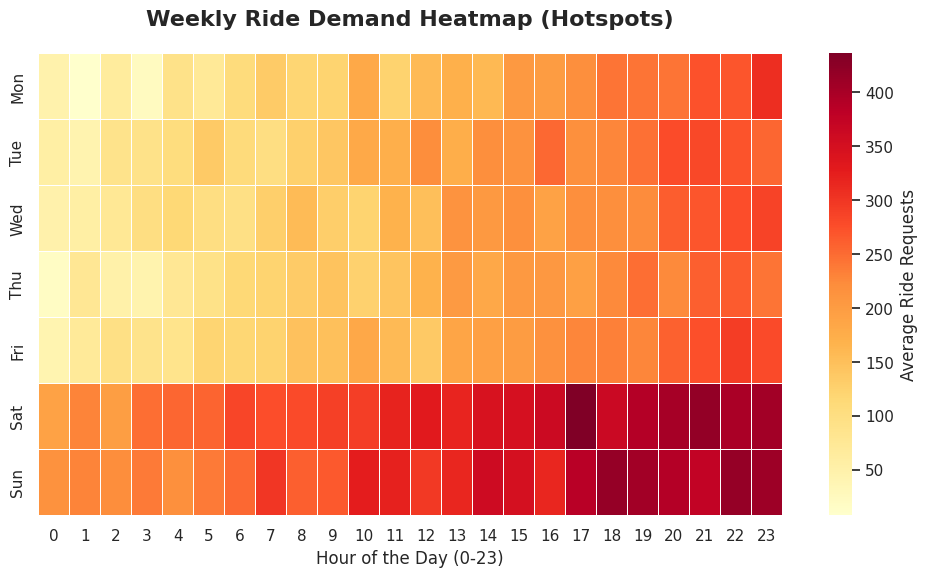

In [2]:
plt.figure(figsize=(12, 6))

# 1. Pivot the data to create a Matrix (Rows = Days, Columns = Hours)
traffic_matrix = df.pivot_table(index='Day', columns='Hour', values='Ride_Requests', aggfunc='mean')

# 2. Create the Heatmap
# cmap='YlOrRd' means Yellow-to-Orange-to-Red (A Sequential palette!)
sns.heatmap(traffic_matrix, cmap='YlOrRd', linewidths=.5, cbar_kws={'label': 'Average Ride Requests'})

plt.title('Weekly Ride Demand Heatmap (Hotspots)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('')
plt.xlabel('Hour of the Day (0-23)')

plt.show()

*(Insight: Without reading a single number, your eye is instantly drawn to the dark red clusters. You can immediately tell the Operations team to deploy more drivers on Friday and Saturday nights!)*

# 2. Small Multiples / Facet Grids (Splitting Dimensions)
Let's say we want to see how ride demand grows throughout the day, but we need to compare all 4 Regions. If we put 4 lines on one chart, they will overlap and become a confusing mess. 

Instead, we use **Small Multiples** (called a FacetGrid in Seaborn). We split the data into multiple miniature charts that share the exact same X and Y axes, making them perfectly comparable.

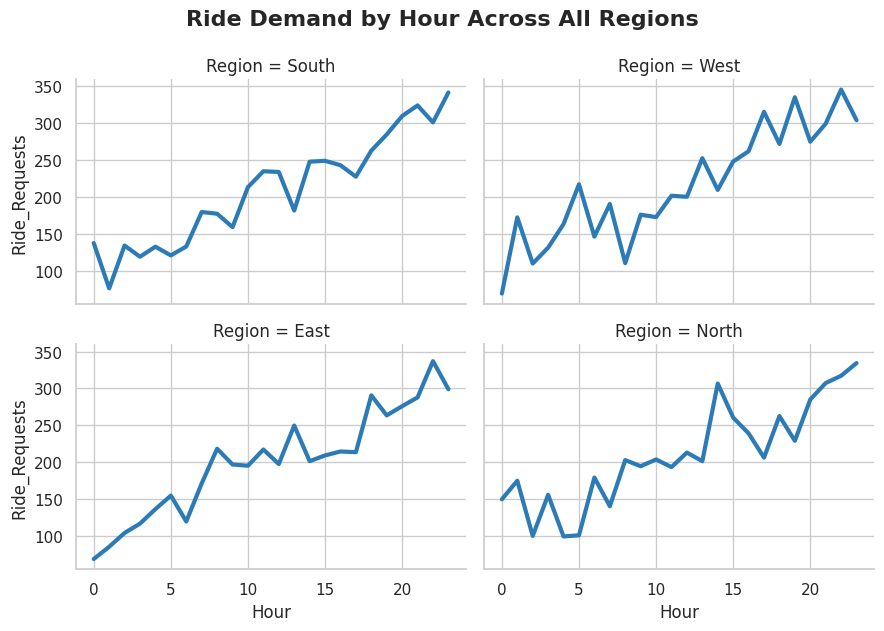

In [3]:
# Create a FacetGrid using seaborn's relplot (Relational Plot)
# col='Region' tells Seaborn to create a separate chart for every Region!
# col_wrap=2 means "Put 2 charts per row"

g = sns.relplot(
    data=df, x='Hour', y='Ride_Requests', col='Region', 
    kind='line', errorbar=None, col_wrap=2, 
    height=3, aspect=1.5, linewidth=3, color='#2c7bb6'
)

g.fig.suptitle('Ride Demand by Hour Across All Regions', fontsize=16, fontweight='bold', y=1.05)
plt.show()

*(Insight: By splitting them up, we avoid the "spaghetti chart." We can easily see the individual trends for each region without any visual clutter fighting for our attention.)*

# 3. Violin Plots (Advanced Distributions)
In Lesson 02, we used Boxplots to compare distributions. Boxplots are great, but they hide the *shape* of the data inside the box. 

A **Violin Plot** combines a Boxplot with a KDE (Kernel Density Estimate) curve. It shows you the exact shape of the data's distribution, revealing hidden "bumps" (bimodal distributions) that a boxplot would completely mask.

/tmp/ipykernel_10930/2204212422.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Region', y='Ride_Requests', palette='muted', inner='quartile')


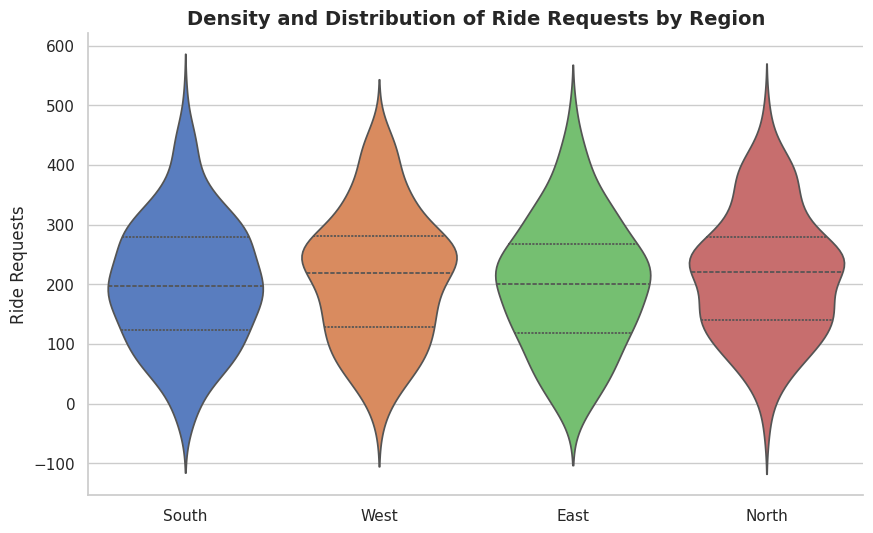

In [4]:
plt.figure(figsize=(10, 6))

# Create the Violin Plot
sns.violinplot(data=df, x='Region', y='Ride_Requests', palette='muted', inner='quartile')

plt.title('Density and Distribution of Ride Requests by Region', fontsize=14, fontweight='bold')
plt.ylabel('Ride Requests')
plt.xlabel('')
sns.despine()

plt.show()

*(Insight: Look closely at the "bulges" in the violins. A wider section means more data points fell into that specific price range. If a violin looks like a figure-8, it means you have two distinct types of customers in that region!)*

# 4. Stacked Area Charts (Composition Over Time)
If you want to show how a *Total* value changes over time, while simultaneously showing what *Categories* make up that total, you use a Stacked Area Chart. 

This is highly effective for showing things like Market Share or Revenue breakdowns over the course of a year.

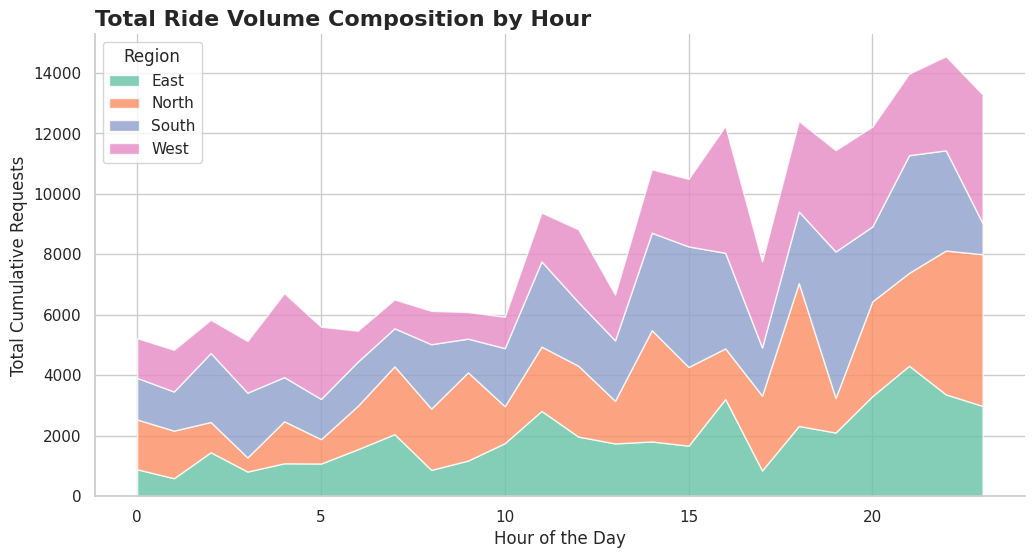

In [5]:
# 1. Group data by Hour and Region to get totals
hourly_region = df.groupby(['Hour', 'Region'])['Ride_Requests'].sum().unstack()

plt.figure(figsize=(12, 6))

# 2. Create the Stacked Area Plot using matplotlib
plt.stackplot(hourly_region.index, 
              hourly_region['East'], hourly_region['North'], 
              hourly_region['South'], hourly_region['West'], 
              labels=['East', 'North', 'South', 'West'],
              alpha=0.8, colors=sns.color_palette("Set2"))

plt.title('Total Ride Volume Composition by Hour', fontsize=16, fontweight='bold', loc='left')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Cumulative Requests')
plt.legend(loc='upper left', title='Region')

# Remove borders
sns.despine()

plt.show()

*(Insight: The top edge of the entire shape shows the total company volume, while the colored bands inside show exactly how much each Region contributed to that total at any given hour.)*

## Real-World Use Case or Analogy:
Think of Advanced Charts like an **Air Traffic Control Tower**:

* **Basic Charts (The Altimeter)**: You are tracking a single plane. A line chart easily shows its altitude over time. Simple and effective.
* **The Heatmap (The Global Radar)**: You need to know the density of traffic across the entire United States airspace. You don't want to see 5,000 individual dots; you want a Heatmap showing a massive, glowing red hotspot over Chicago so you can reroute incoming flights.
* **Small Multiples (Altitude Layers)**: You have too many planes on the screen. If you look at them all at once, they overlap and look like they are crashing. The controller splits the screen into four smaller screens (Small Multiples): one for planes at 10,000 ft, one for 20,000 ft, etc. The visual noise is instantly organized.
* **Violin Plot (The Holding Pattern)**: A boxplot tells you the average plane in the holding pattern is 5 miles away. But a Violin plot shows you the *shape* of the cluster, revealing that half the planes are tightly grouped 2 miles away, and the other half are 8 miles away—a critical difference that the boxplot's simple "average" completely hid!

---